# Employee Attrition Prediction Project
This notebook demonstrates the process of predicting employee attrition using machine learning. It covers data loading, cleaning, exploratory data analysis (EDA), model training, and evaluation with various metrics.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

## 2. Load and Preview Data

In [2]:
# Load dataset
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 3. Data Cleaning and Preprocessing

In [3]:
# Drop irrelevant columns
df.drop(['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'], axis=1, inplace=True)
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})
# Encode categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le
df.head()

C:\Users\bisma\AppData\Local\Temp\ipykernel_13216\2563940542.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


## 4. Exploratory Data Analysis (EDA)

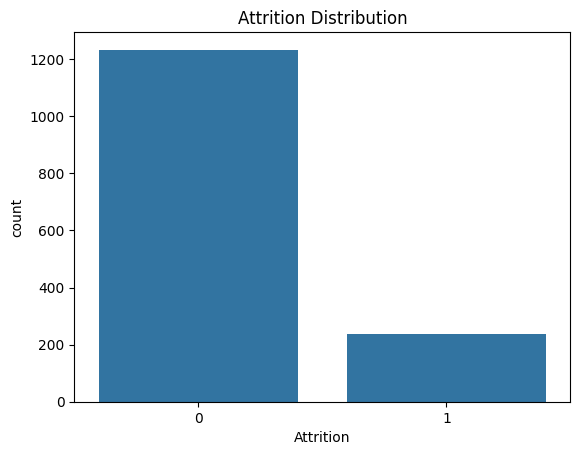

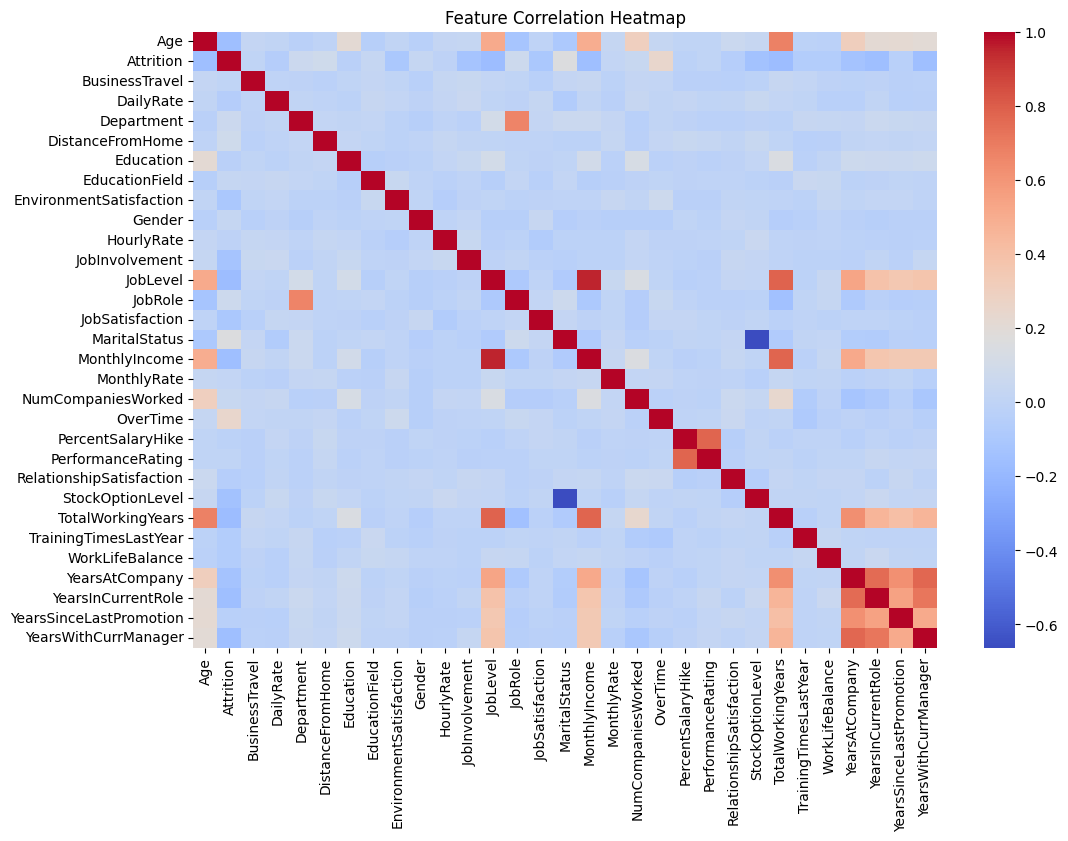

In [4]:
# Attrition distribution
sns.countplot(x='Attrition', data=df)
plt.title('Attrition Distribution')
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

## 5. Data Splitting and Scaling

In [5]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 6. Model Training

In [6]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## 7. Model Evaluation Metrics

Accuracy: 0.8333
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.43      0.13      0.20        47

    accuracy                           0.83       294
   macro avg       0.64      0.55      0.55       294
weighted avg       0.79      0.83      0.79       294



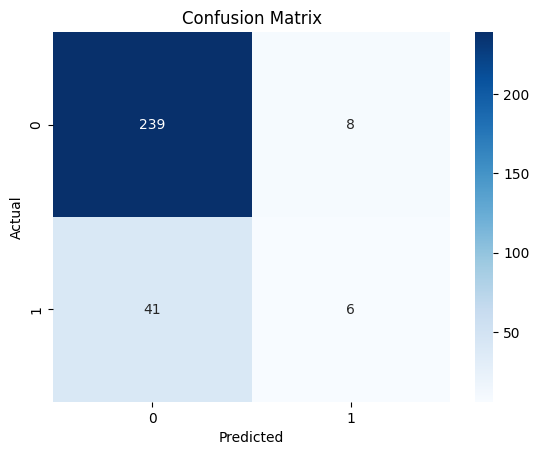

ROC-AUC Score: 0.7780


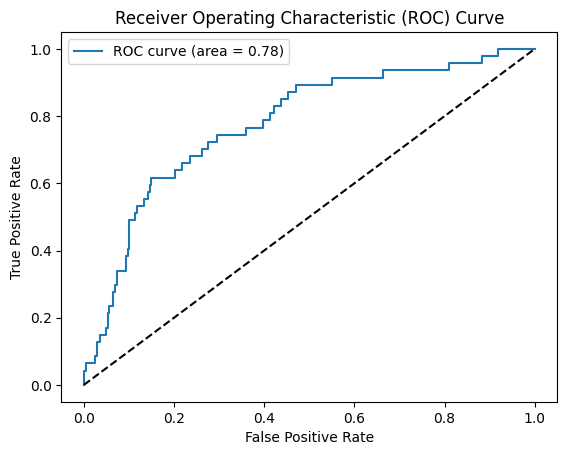

In [7]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.4f}')

# Classification report
print('Classification Report:')
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_proba)
print(f'ROC-AUC Score: {roc_auc:.4f}')


# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math

mse = mean_squared_error(y_test, y_proba)
mae = mean_absolute_error(y_test, y_proba)
rmse = math.sqrt(mse)
r2 = r2_score(y_test, y_proba)
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f'MSE: {mse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R2 Score: {r2:.4f}')
print(f'Adjusted R2 Score: {adj_r2:.4f}')

MSE: 0.1170
MAE: 0.2531
RMSE: 0.3421
R2 Score: 0.1286
Adjusted R2 Score: 0.0292


In [9]:
# internal cross validation for demonstration (not used in final model)

d:\Python Project\temp_project\Employee-Attrition\myvenv\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
d:\Python Project\temp_project\Employee-Attrition\myvenv\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


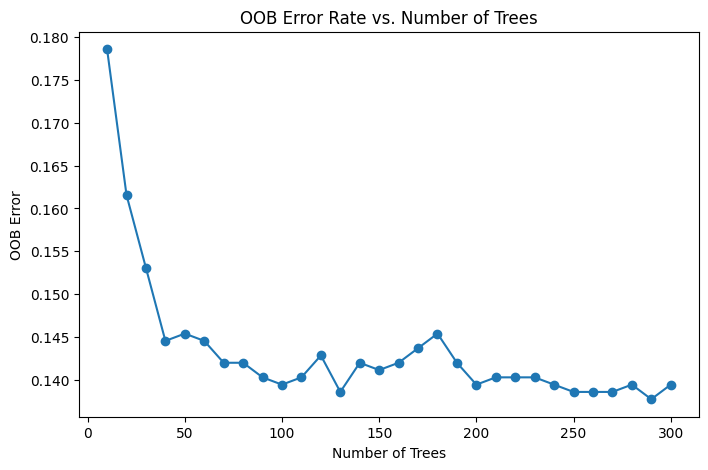

In [10]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

oob_errors = []
n_estimators_range = range(10, 301, 10)

for n in n_estimators_range:
    rf = RandomForestClassifier(
        n_estimators=n,
        oob_score=True,
        random_state=42,
        max_depth=15,
        min_samples_split=5,
        class_weight='balanced'
    )
    rf.fit(X_train, y_train)
    oob_error = 1 - rf.oob_score_
    oob_errors.append(oob_error)

plt.figure(figsize=(8,5))
plt.plot(n_estimators_range, oob_errors, marker='o')
plt.xlabel('Number of Trees')
plt.ylabel('OOB Error')
plt.title('OOB Error Rate vs. Number of Trees')
plt.show()

## 8. Save Model for Flask Application
Create a pipeline with preprocessing and save for production use.

In [11]:
import pickle
import os
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Reload fresh data for pipeline
df_fresh = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df_fresh.drop(['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'], axis=1, inplace=True)
df_fresh['Attrition'] = df_fresh['Attrition'].map({'Yes': 1, 'No': 0})

X_fresh = df_fresh.drop('Attrition', axis=1)
y_fresh = df_fresh['Attrition']

# Identify column types
cat_cols = X_fresh.select_dtypes(include='object').columns.tolist()
num_cols = X_fresh.select_dtypes(exclude='object').columns.tolist()

print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')
print(f'Numerical columns ({len(num_cols)}): {num_cols}')

Categorical columns (7): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Numerical columns (23): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


C:\Users\bisma\AppData\Local\Temp\ipykernel_13216\763683560.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_fresh.select_dtypes(include='object').columns.tolist()


In [12]:
# Create preprocessor that handles both numerical and categorical features
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# Create full pipeline with preprocessing built-in
pipeline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42
    ))
])

# Split data
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_fresh, y_fresh, test_size=0.2, random_state=42, stratify=y_fresh
)

# Train pipeline
print('Training pipeline model...')
pipeline_model.fit(X_train_p, y_train_p)
print('Training complete!')

Training pipeline model...
Training complete!


In [13]:
# Evaluate pipeline model
y_pred_p = pipeline_model.predict(X_test_p)
y_proba_p = pipeline_model.predict_proba(X_test_p)[:, 1]

# Calculate metrics
metrics = {
    'accuracy': float(accuracy_score(y_test_p, y_pred_p)),
    'precision': float(precision_score(y_test_p, y_pred_p, zero_division=0)),
    'recall': float(recall_score(y_test_p, y_pred_p, zero_division=0)),
    'f1_score': float(f1_score(y_test_p, y_pred_p, zero_division=0)),
    'roc_auc': float(roc_auc_score(y_test_p, y_proba_p))
}

print('=== Pipeline Model Performance ===')
for k, v in metrics.items():
    print(f'{k.upper()}: {v:.4f}')

=== Pipeline Model Performance ===
ACCURACY: 0.8401
PRECISION: 0.5000
RECALL: 0.1277
F1_SCORE: 0.2034
ROC_AUC: 0.7928


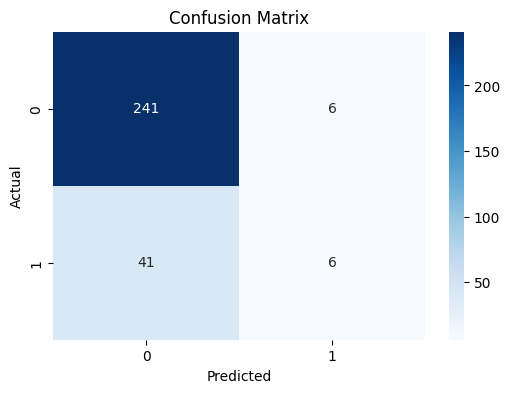

Confusion matrix saved to static/confusion.png


In [14]:
# Save confusion matrix image
os.makedirs('static', exist_ok=True)

cm = confusion_matrix(y_test_p, y_pred_p)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('static/confusion.png', dpi=100, bbox_inches='tight')
plt.show()

print('Confusion matrix saved to static/confusion.png')

In [15]:
# Save model and metrics for Flask app
pickle.dump(pipeline_model, open('model.pkl', 'wb'))
pickle.dump(metrics, open('metrics.pkl', 'wb'))

print('Model saved as model.pkl')
print('Metrics saved as metrics.pkl')
print('\nFlask app can now use these files!')

Model saved as model.pkl
Metrics saved as metrics.pkl

Flask app can now use these files!
